# M3: outlier participants, and does the HC-vs-PD offset survive without them

`PLANScores.md` M3: boxplots of each feature by group, every subject's own value scattered and labeled (id minus `MET`), to spot (a) which CTR/PD participants land inside deutan's range and (b) which participants look unlike their own group -- a possible sign of an acquired or unusual deficiency. Outliers are flagged with the standard Tukey rule (`comparisons.tukey_outlier_mask`, the same 1.5xIQR-beyond-the-box definition matplotlib's own boxplot fliers use), per feature, against each subject's own group.

Then: does `04_hc_vs_pd.ipynb`'s 'PD looks like HC + a constant' offset hold up if the CTR subjects who look most unlike the rest of CTR are dropped first? Per-M3 exclusion rule: a CTR subject is dropped if they're flagged an outlier on a majority of the 6 features (`comparisons.MAJORITY_FEATURES`, 4 of 6) -- a much stricter bar than any single feature, so only a subject who's unusual almost everywhere gets excluded.

In [1]:
import sys
sys.path.append('../scripts')

import comparisons
import loader
import plotting

df = loader.load_fm100_raw()
categories = [
    {'label': 'CTR', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

## Feature distributions, all four groups

Filled/white-edge points are within their own group's normal range; black-edge bold-labeled points are Tukey outliers on that specific feature. Reading across panels for a given id shows how many features flag the same subject -- and reading a CTR/PD point's height against deutan's box shows whether that individual already looks deutan-like on this feature, without any extra computed flag (a visual read, per your call).

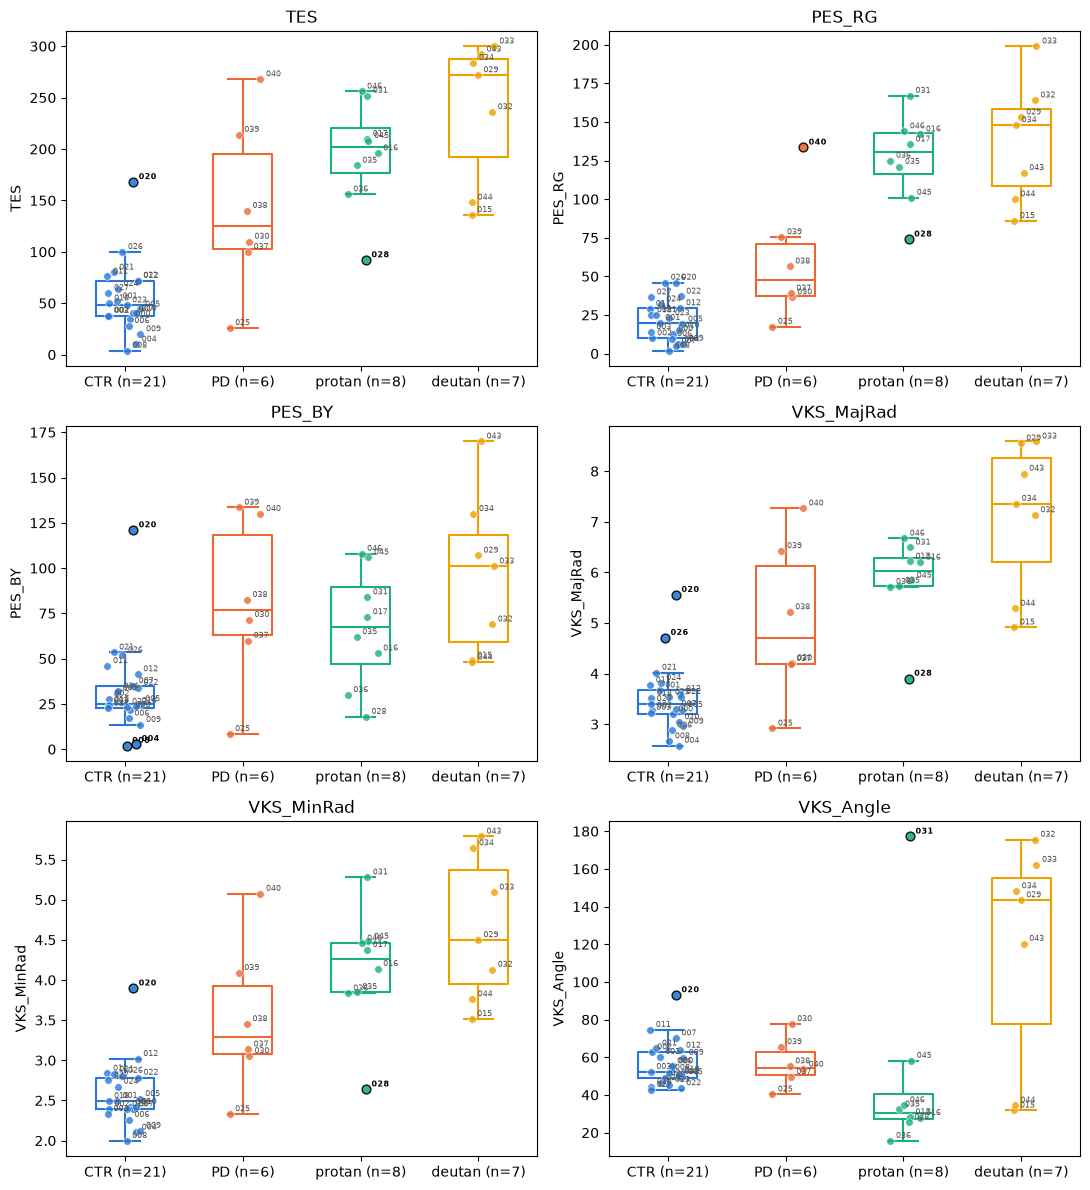

In [2]:
plotting.plot_feature_boxplots_grid(df, categories);

## Which CTR subjects are outliers on most/all features

`comparisons.subject_feature_outliers` -- one row per CTR subject, one bool per feature, `n_flagged` counts how many. The exclusion rule below keeps only `n_flagged >= comparisons.MAJORITY_FEATURES`.

In [3]:
ctr_outliers = comparisons.subject_feature_outliers(df, group='CTR')
ctr_outliers.sort_values('n_flagged', ascending=False)

,sub_id,TES,PES_RG,PES_BY,VKS_MajRad,VKS_MinRad,VKS_Angle,n_flagged
14,MET020,True,False,True,True,True,True,5
8,MET008,False,False,True,False,False,False,1
19,MET026,False,False,False,True,False,False,1
4,MET004,False,False,True,False,False,False,1
0,MET000,False,False,False,False,False,False,0
3,MET003,False,False,False,False,False,False,0
2,MET002,False,False,False,False,False,False,0
1,MET001,False,False,False,False,False,False,0
5,MET005,False,False,False,False,False,False,0
9,MET009,False,False,False,False,False,False,0


In [4]:
majority_outliers = ctr_outliers.loc[ctr_outliers['n_flagged'] >= comparisons.MAJORITY_FEATURES, 'sub_id'].tolist()
majority_outliers

['MET020']

## Rerunning the HC-vs-PD offset without them

Same `comparisons.estimate_offset` call as `04_hc_vs_pd.ipynb`, HC's subject list filtered to drop `majority_outliers` first, PD unchanged.

In [5]:
full_ctr_ids = loader.subjects_in_group(df, group='CTR')
trimmed_ctr_ids = [s for s in full_ctr_ids if s not in majority_outliers]
print(f"CTR n: {len(full_ctr_ids)} -> {len(trimmed_ctr_ids)} after dropping {majority_outliers}")

hc_profiles_trimmed = plotting.group_profiles(df, sub_ids=trimmed_ctr_ids)
pd_profiles = plotting.group_profiles(df, group='PD')
offset_trimmed = comparisons.estimate_offset(hc_profiles_trimmed, pd_profiles, n_boot=2000, seed=0)
offset_trimmed

CTR n: 21 -> 20 after dropping ['MET020']


{'offset': 1.1113725490196078,
 'ci_lower': 0.3423235294117647,
 'ci_upper': 1.860539215686274,
 'p_value': 0.0009995002498750624,
 'r_squared': 0.4651349629531222}

In [6]:
hc_profiles_full = plotting.group_profiles(df, group='CTR')
offset_full = comparisons.estimate_offset(hc_profiles_full, pd_profiles, n_boot=2000, seed=0)
import pandas as pd
pd.DataFrame([{'CTR': 'full (n=21)', **offset_full}, {'CTR': f'trimmed (n={len(trimmed_ctr_ids)})', **offset_trimmed}])

,CTR,offset,ci_lower,ci_upper,p_value,r_squared
0,full (n=21),1.044444,0.316475,1.806951,0.002999,0.504635
1,trimmed (n=20),1.111373,0.342324,1.860539,0.001000,0.465135


**The pattern isn't driven by one outlier.** Only one CTR subject (MET020, already one of this project's own flagged edge cases -- see `03_flagged_subjects.ipynb`) clears the majority-outlier bar, and dropping them barely moves the offset (1.04 -> 1.11) while tightening the p-value (0.0030 -> 0.0010, both well under 0.05 either way). R2 doesn't improve either (0.505 -> 0.465) -- if anything it's slightly worse, so the roughly-half-explained shape isn't something MET020 alone was obscuring or inflating. 'PD looks like HC + a constant' reads as a genuine group-level pattern, not an artifact of one unusual control.